# Baseline: Logistic Regression (All Features)

## Overview
This notebook establishes a comprehensive baseline using Logistic Regression on the full feature set. It includes:

1. **Majority Class Baseline**: Simple baseline for comparison
2. **Hyperparameter Tuning**: C-parameter grid search with 5-fold stratified cross-validation
3. **Custom Business Metrics**: Evaluation using both penalized and non-penalized business scorers
4. **Threshold Optimization**: Decision threshold discovery to maximize business metrics
5. **Detailed Analysis**: Visualizations and comprehensive performance metrics

## Key Metrics
- **Business Score (with penalty)**: TP × 10 - FP × 5 - Features × 200
- **Business Score (no penalty)**: TP × 10 - FP × 5
- **F1 Score**: Standard harmonic mean of precision and recall

## Pipeline
- Data loading and robust scaling
- 5-fold stratified cross-validation
- Grid search over C ∈ [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
- Class-balanced logistic regression
- Threshold sweep and analysis

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import RobustScaler

from cost_effective.dataset.utils import business_scorer_no_var_penalty, custom_scorer

sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 11

PROJECT_ROOT: Path = Path().resolve().parent
DATA_PATH: Path = PROJECT_ROOT / "data"
OUTPUTS_PATH: Path = PROJECT_ROOT / "outputs"

In [2]:
X_train = pd.read_csv(
    DATA_PATH / "x_train.txt",
    sep=r"\s+",
    header=None,
    skiprows=1,
    low_memory=False,
).apply(pd.to_numeric, errors="coerce")
X_train = pd.DataFrame(
    RobustScaler().fit_transform(X_train.fillna(0.0)),
    columns=[f"var_{i}" for i in range(X_train.shape[1])],
)

y_train = pd.read_csv(DATA_PATH / "y_train.txt", header=None, skiprows=1).iloc[:, 0].astype(int)
print(f"Loaded X_train: {X_train.shape}, y_train: {y_train.shape}")

Loaded X_train: (5000, 500), y_train: (5000,)


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
majority_clf = DummyClassifier(strategy="most_frequent")

baseline_cv_results = cross_validate(
    majority_clf,
    X_train.values,
    y_train.values,
    cv=cv,
    scoring={
        "business_with_var_penalty": custom_scorer,
        "business_no_var_penalty": business_scorer_no_var_penalty,
        "f1": "f1",
    },
    n_jobs=-1,
)

baseline_summary = {
    "business_with_var_penalty": {
        "mean": float(baseline_cv_results["test_business_with_var_penalty"].mean()),
        "std": float(baseline_cv_results["test_business_with_var_penalty"].std()),
    },
    "business_no_var_penalty": {
        "mean": float(baseline_cv_results["test_business_no_var_penalty"].mean()),
        "std": float(baseline_cv_results["test_business_no_var_penalty"].std()),
    },
    "f1": {
        "mean": float(baseline_cv_results["test_f1"].mean()),
        "std": float(baseline_cv_results["test_f1"].std()),
    },
}

no_pen_mean = baseline_summary["business_no_var_penalty"]["mean"]
no_pen_std = baseline_summary["business_no_var_penalty"]["std"]
with_pen_mean = baseline_summary["business_with_var_penalty"]["mean"]
with_pen_std = baseline_summary["business_with_var_penalty"]["std"]
print(f"Business Score (no penalty): {no_pen_mean:.2f} ± {no_pen_std:.2f}")
print(f"Business Score (with penalty): {with_pen_mean:.2f} ± {with_pen_std:.2f}")
print()

print("Majority Baseline Results (5-fold CV):")
pd.DataFrame(baseline_summary).T

Business Score (no penalty): 0.00 ± 0.00
Business Score (with penalty): -100000.00 ± 0.00

Majority Baseline Results (5-fold CV):


,mean,std
business_with_var_penalty,-100000.0,0.0
business_no_var_penalty,0.0,0.0
f1,0.0,0.0


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_values = [
    1e-9,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    30.0,
    100.0,
]

lr_results = []
for C in C_values:
    clf = LogisticRegression(
        max_iter=2000, C=C, class_weight="balanced", random_state=42, solver="lbfgs"
    )
    cv_results = cross_validate(
        clf,
        X_train.values,
        y_train.values,
        cv=cv,
        scoring={
            "business_with_var_penalty": custom_scorer,
            "business_no_var_penalty": business_scorer_no_var_penalty,
            "f1": "f1",
        },
        n_jobs=-1,
    )
    lr_results.append({
        "C": C,
        "business_mean": cv_results["test_business_with_var_penalty"].mean(),
        "business_std": cv_results["test_business_with_var_penalty"].std(),
        "business_no_var_mean": cv_results["test_business_no_var_penalty"].mean(),
        "business_no_var_std": cv_results["test_business_no_var_penalty"].std(),
        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),
        "cv_results": cv_results,
    })

lr_grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != "cv_results"} for r in lr_results])

# Select best C by business score
best_c_idx = lr_grid_df["business_mean"].idxmax()
best_result = lr_results[best_c_idx]
best_c = best_result["C"]
print(f"Best C value: {best_c} (business_score: {best_result['business_mean']:.2f})")
print()

print("Logistic Regression Grid Results:")
lr_grid_df

Best C value: 0.001 (business_score: -97534.00)

Logistic Regression Grid Results:


,C,business_mean,business_std,business_no_var_mean,business_no_var_std,f1_mean,f1_std
0,1.000000e-09,-97536.0,7.348469,2464.0,7.348469,0.572915,0.008627
1,1.000000e-05,-97536.0,7.348469,2464.0,7.348469,0.570296,0.008056
2,3.000000e-05,-97536.0,7.348469,2464.0,7.348469,0.571986,0.011705
3,1.000000e-04,-97536.0,7.348469,2464.0,7.348469,0.572490,0.013769
4,3.000000e-04,-97537.0,10.295630,2463.0,10.295630,0.571413,0.016533
5,1.000000e-03,-97534.0,45.541190,2466.0,45.541190,0.571621,0.016572
6,3.000000e-03,-97628.0,23.151674,2372.0,23.151674,0.559933,0.019140
7,1.000000e-02,-97751.0,52.952809,2249.0,52.952809,0.549415,0.017660
8,3.000000e-02,-97807.0,34.146742,2193.0,34.146742,0.547982,0.017060
9,1.000000e-01,-97853.0,54.369109,2147.0,54.369109,0.544993,0.015692


In [ ]:
# Save results for best LogisticRegression and compare with majority baseline
best_cv_results = best_result["cv_results"]

results = {
    "majority_baseline": {
        "business_with_var_penalty": baseline_cv_results["test_business_with_var_penalty"].tolist(),
        "business_no_var_penalty": baseline_cv_results["test_business_no_var_penalty"].tolist(),
        "f1": baseline_cv_results["test_f1"].tolist(),
    },
    "logistic_regression_best": {
        "C": float(best_c),
        "business_with_var_penalty": best_cv_results["test_business_with_var_penalty"].tolist(),
        "business_no_var_penalty": best_cv_results["test_business_no_var_penalty"].tolist(),
        "f1": best_cv_results["test_f1"].tolist(),
    },
}

summary = {}
for model_name, metrics in results.items():
    if model_name == "logistic_regression_best":
        c_value = metrics.pop("C")
        summary[f"logistic_regression (C={c_value})"] = {
            k: {
                "mean": float(np.mean(v)),
                "std": float(np.std(v)),
            }
            for k, v in metrics.items()
        }
    else:
        summary[model_name] = {
            k: {
                "mean": float(np.mean(v)),
                "std": float(np.std(v)),
            }
            for k, v in metrics.items()
        }

out_path = OUTPUTS_PATH / "baseline_results.json"
with out_path.open("w", encoding="utf-8") as fh:
    json.dump({"results": results, "summary": summary}, fh, indent=2)

print(f"Saved results to {out_path.relative_to(PROJECT_ROOT)}")
pd.DataFrame(summary).T

Saved results to outputs/baseline_results.json


,business_with_var_penalty,business_no_var_penalty,f1
majority_baseline,"{'mean': -100000.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}"
logistic_regression (C=0.001),"{'mean': -97534.0, 'std': 45.5411901469428}","{'mean': 2466.0, 'std': 45.5411901469428}","{'mean': 0.5716211993738101, 'std': 0.01657232..."


In [ ]:
# Threshold discovery using best LogisticRegression model
best_clf = LogisticRegression(
    max_iter=2000, C=best_c, class_weight="balanced", random_state=42, solver="lbfgs"
)

probs = cross_val_predict(
    best_clf, X_train.values, y_train.values, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.0, 1.0, 101)
results_by_threshold = []

n_features = X_train.shape[1]
for threshold in thresholds:
    pred = (probs > threshold).astype(int)
    tp = ((pred == 1) & (y_train.values == 1)).sum()
    fp = ((pred == 1) & (y_train.values == 0)).sum()
    f1 = f1_score(y_train.values, pred, zero_division=0)
    business_score = (tp * 10) - (fp * 5) - (n_features * 200)
    results_by_threshold.append({
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "f1": f1,
        "business_score": business_score,
    })

results_df = pd.DataFrame(results_by_threshold)
best_idx = results_df["business_score"].idxmax()
best_row = results_df.iloc[best_idx]

print(f"Optimal threshold: {best_row['threshold']:.3f}")
print(f"  TP: {best_row['tp']}")
print(f"  FP: {best_row['fp']}")
print(f"  F1 @ optimal: {best_row['f1']:.4f}")
print(f"  Business score: {best_row['business_score']:.0f}")
print()

# Show top 5 thresholds
print("Top 5 thresholds by business score:")
results_df.nlargest(5, "business_score")[["threshold", "tp", "fp", "f1", "business_score"]]

Optimal threshold: 0.290
  TP: 2478.0
  FP: 2488.0
  F1 @ optimal: 0.6649
  Business score: -87660

Top 5 thresholds by business score:


,threshold,tp,fp,f1,business_score
29,0.29,2478,2488,0.664878,-87660
33,0.33,2444,2420,0.664853,-87660
27,0.27,2482,2498,0.664703,-87670
21,0.21,2487,2509,0.664618,-87675
22,0.22,2487,2509,0.664618,-87675


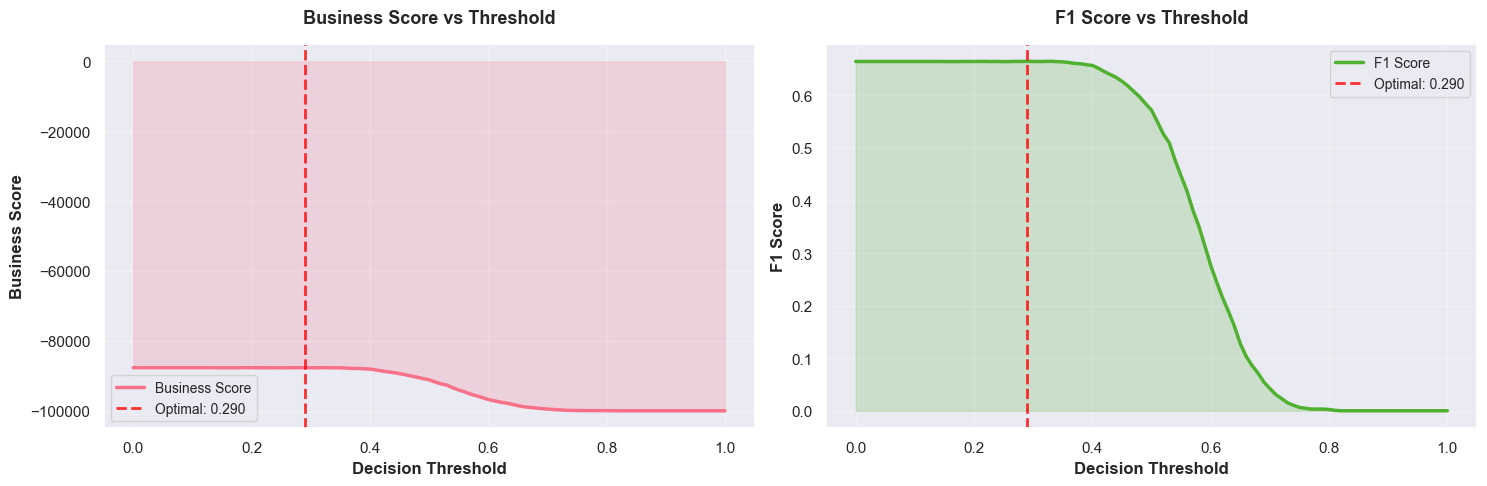

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Business Score plot
sns.lineplot(
    x="threshold",
    y="business_score",
    data=results_df,
    linewidth=2.5,
    color=sns.color_palette("husl")[0],
    ax=ax1,
    label="Business Score",
)
ax1.axvline(
    best_row["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=f"Optimal: {best_row['threshold']:.3f}",
)
ax1.fill_between(
    results_df["threshold"],
    results_df["business_score"],
    alpha=0.2,
    color=sns.color_palette("husl")[0],
)
ax1.set_xlabel("Decision Threshold", fontsize=12, fontweight="bold")
ax1.set_ylabel("Business Score", fontsize=12, fontweight="bold")
ax1.set_title("Business Score vs Threshold", fontsize=13, fontweight="bold", pad=15)
ax1.legend(fontsize=10, loc="best")
ax1.grid(True, alpha=0.3)

# F1 Score plot
sns.lineplot(
    x="threshold",
    y="f1",
    data=results_df,
    linewidth=2.5,
    color=sns.color_palette("husl")[2],
    ax=ax2,
    label="F1 Score",
)
ax2.axvline(
    best_row["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=f"Optimal: {best_row['threshold']:.3f}",
)
ax2.fill_between(
    results_df["threshold"], results_df["f1"], alpha=0.2, color=sns.color_palette("husl")[2]
)
ax2.set_xlabel("Decision Threshold", fontsize=12, fontweight="bold")
ax2.set_ylabel("F1 Score", fontsize=12, fontweight="bold")
ax2.set_title("F1 Score vs Threshold", fontsize=13, fontweight="bold", pad=15)
ax2.legend(fontsize=10, loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
threshold_config = {
    "optimal_threshold": float(best_row["threshold"]),
    "business_score": float(best_row["business_score"]),
    "tp": int(best_row["tp"]),
    "fp": int(best_row["fp"]),
    "f1": float(best_row["f1"]),
}

threshold_path = OUTPUTS_PATH / "optimal_threshold.json"
with threshold_path.open("w", encoding="utf-8") as f:
    json.dump(threshold_config, f, indent=2)

print(f"✓ Saved optimal threshold to {threshold_path.relative_to(PROJECT_ROOT)}")
print(f"  Threshold: {threshold_config['optimal_threshold']:.3f}")

✓ Saved optimal threshold to outputs/optimal_threshold.json
  Threshold: 0.290
